In [14]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

# Reliance Industries Ltd. Analysis

In [16]:
def get_data(start_date, end_date):
    ticker = "RELIANCE.NS"
    
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1d"   
    )

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    return data

In [18]:
data = get_data("2017-01-01", "2025-12-31")

[*********************100%***********************]  1 of 1 completed


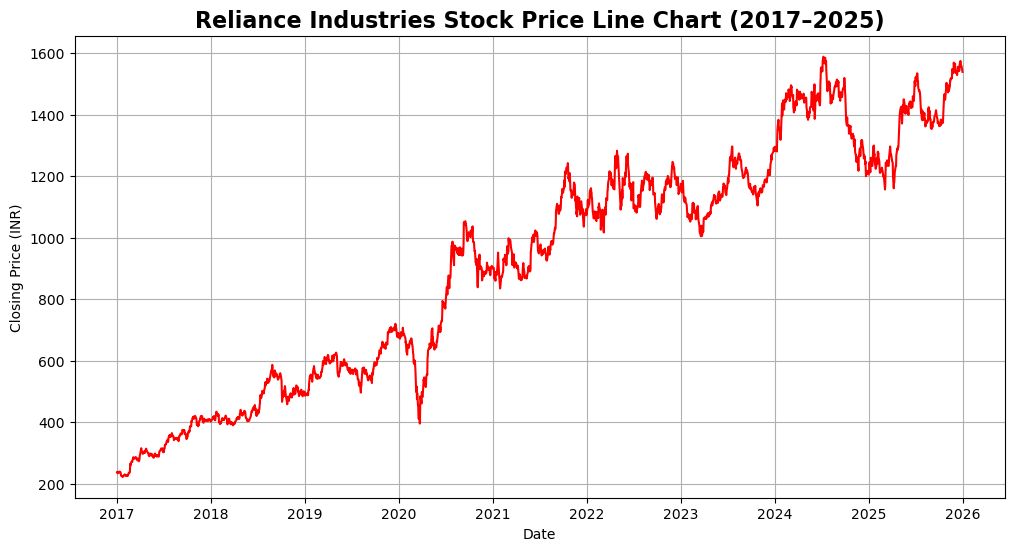

In [20]:
# Line chart 
plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"], color='red')
plt.title("Reliance Industries Stock Price Line Chart (2017–2025)", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.grid()
plt.show()

In [23]:
# The line chart shows an overall upward trend in closing prices, indicating long-term growth of the stock,
# while the fluctuations in between suggest short-term volatility and market variability.

### Trend Analysis Using Moving Averages

In [22]:
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()
data

Price,Close,High,Low,Open,Volume,MA20,MA50
Date,,,,,,,
2017-01-02,237.771011,238.844716,234.977178,237.529968,7097888,NaN,NaN
2017-01-03,238.713257,240.378607,236.894539,238.811874,6434204,NaN,NaN
2017-01-04,233.837723,239.502067,233.213224,239.480155,10392483,NaN,NaN
2017-01-05,236.083755,236.631563,234.188347,234.681375,8734164,NaN,NaN
2017-01-06,235.546906,237.749108,235.141524,235.382568,7845839,NaN,NaN
...,...,...,...,...,...,...,...
2025-12-23,1570.699951,1580.900024,1568.099976,1580.900024,7506564,1551.875006,1508.874006
2025-12-24,1558.199951,1575.699951,1553.599976,1572.699951,8815745,1551.290002,1512.538005
2025-12-26,1559.199951,1561.000000,1554.300049,1554.699951,2311495,1551.079999,1516.204004


In [24]:
data['Trend'] = 'Downtrend'
data.loc[data['MA20'] > data['MA50'], 'Trend'] = 'Uptrend'
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend
Date,,,,,,,,
2017-01-02,237.771011,238.844716,234.977178,237.529968,7097888,NaN,NaN,Downtrend
2017-01-03,238.713257,240.378607,236.894539,238.811874,6434204,NaN,NaN,Downtrend
2017-01-04,233.837723,239.502067,233.213224,239.480155,10392483,NaN,NaN,Downtrend
2017-01-05,236.083755,236.631563,234.188347,234.681375,8734164,NaN,NaN,Downtrend
2017-01-06,235.546906,237.749108,235.141524,235.382568,7845839,NaN,NaN,Downtrend
...,...,...,...,...,...,...,...,...
2025-12-23,1570.699951,1580.900024,1568.099976,1580.900024,7506564,1551.875006,1508.874006,Uptrend
2025-12-24,1558.199951,1575.699951,1553.599976,1572.699951,8815745,1551.290002,1512.538005,Uptrend
2025-12-26,1559.199951,1561.000000,1554.300049,1554.699951,2311495,1551.079999,1516.204004,Uptrend


### Daily Returns

In [26]:
data['Daily Return'] = data['Close'].pct_change()
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend,Daily Return
Date,,,,,,,,,
2017-01-02,237.771011,238.844716,234.977178,237.529968,7097888,NaN,NaN,Downtrend,NaN
2017-01-03,238.713257,240.378607,236.894539,238.811874,6434204,NaN,NaN,Downtrend,0.003963
2017-01-04,233.837723,239.502067,233.213224,239.480155,10392483,NaN,NaN,Downtrend,-0.020424
2017-01-05,236.083755,236.631563,234.188347,234.681375,8734164,NaN,NaN,Downtrend,0.009605
2017-01-06,235.546906,237.749108,235.141524,235.382568,7845839,NaN,NaN,Downtrend,-0.002274
...,...,...,...,...,...,...,...,...,...
2025-12-23,1570.699951,1580.900024,1568.099976,1580.900024,7506564,1551.875006,1508.874006,Uptrend,-0.002983
2025-12-24,1558.199951,1575.699951,1553.599976,1572.699951,8815745,1551.290002,1512.538005,Uptrend,-0.007958
2025-12-26,1559.199951,1561.000000,1554.300049,1554.699951,2311495,1551.079999,1516.204004,Uptrend,0.000642


### Handling of missing values

In [39]:
# Replace first NaN in Daily Return
data['Daily Return'].fillna(0)

# Forward fill remaining missing values
data.ffill(inplace=True)

# Remove any remaining initial NaN rows (from MA20, MA50, etc.)
data.dropna(inplace=True)

# Final check
print(data.isnull().sum())

Price
Close           0
High            0
Low             0
Open            0
Volume          0
MA20            0
MA50            0
Trend           0
Daily Return    0
dtype: int64


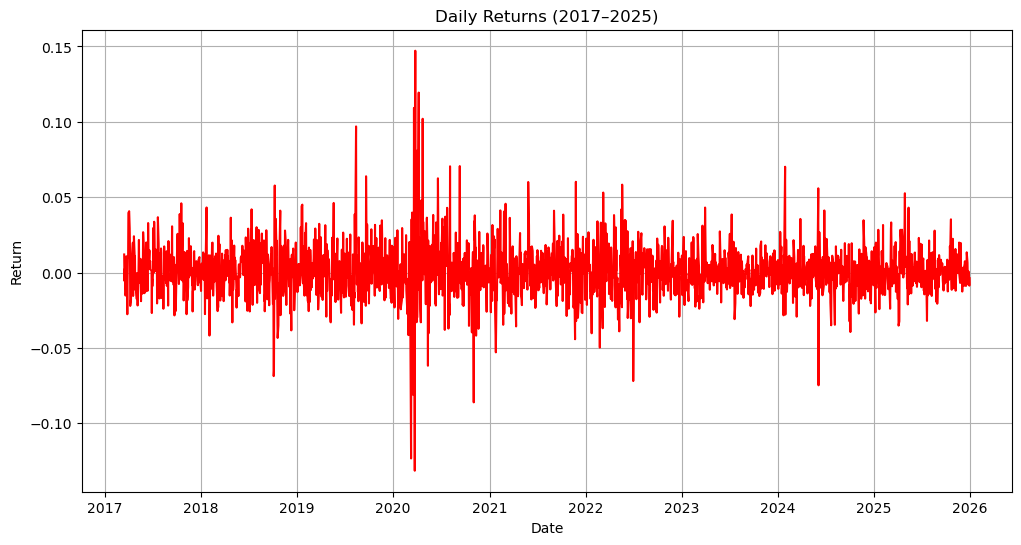

In [41]:
# Line chart (Daily Returns Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Daily Return'], color='red')
plt.title("Daily Returns (2017–2025)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid()
plt.show()

In [43]:
# The daily returns are centered around zero, indicating stable average performance,
# while sharp peaks and dips reflect short-term volatility and occasional market fluctuations.

### Daily Volatility

In [45]:
daily_vol = data['Daily Return'].std()
print(f"Daily Volatility: {daily_vol*100:.2f}%")

Daily Volatility: 1.73%


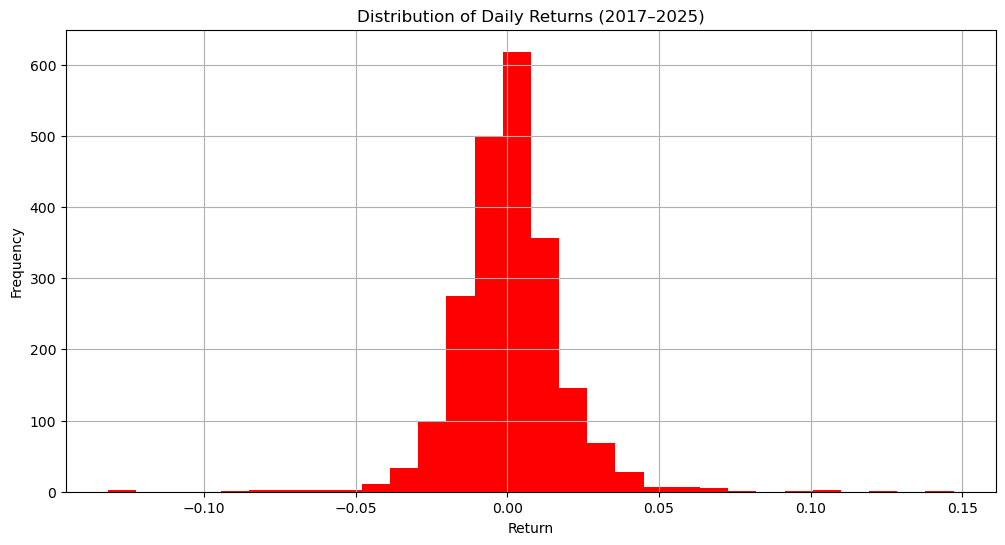

In [47]:
# Histogram (Distribution of Daily Returns)
plt.figure(figsize=(12,6))
plt.hist(data['Daily Return'].dropna(), bins=30, color='red')
plt.title("Distribution of Daily Returns (2017–2025)")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [49]:
# The distribution of daily returns is centered around zero, indicating stable average performance,
# while the spread and presence of extreme values suggest periods of higher volatility in the stock.

### Annualized Volatility

In [51]:
annual_vol = daily_vol * np.sqrt(252)
print(f"Annualized Volatility: {annual_vol*100:.2f}%")

Annualized Volatility: 27.47%


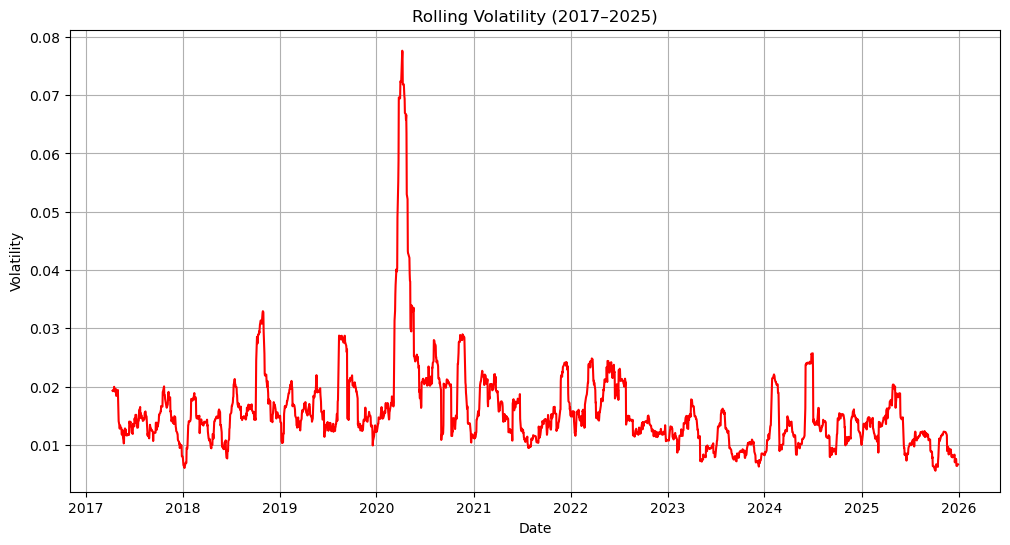

In [53]:
data['Rolling Volatility'] = data['Daily Return'].rolling(20).std()

# Line chart (Rolling Volatility Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Rolling Volatility'], color='red')
plt.title("Rolling Volatility (2017–2025)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid()
plt.show()

In [55]:
# The rolling volatility indicates that market fluctuations are generally low and stable.
# Noticeable spikes around 2020 reflect periods of increased uncertainty and risk.
# In the following years, volatility reduces and becomes more steady, indicating improved market stability.

### 📊 Conclusion

### Reliance stock shows a gradual upward movement with periodic fluctuations over time.

### - Volatility indicates moderate risk with occasional spikes during uncertain periods.

### - Moving averages help in identifying the overall trend direction.

### - Daily returns show fairly consistent performance with some short-term variations.